## 基礎程式

In [8]:
import cv2
import numpy as np
import time  # 導入 time 模組

# 設定影像尺寸
width = 1280
height = 960

# 視頻檔案路徑
video_path = r"C:\Users\skybl\Desktop\大三上_逢甲\進階專題\水鹿影片\水鹿1.mp4"

# 創建 VideoCapture 物件
cap = cv2.VideoCapture(video_path)

# 檢查是否成功打開視頻檔案
if not cap.isOpened():
    print("無法打開視頻檔案")
    exit()


# 計算畫面面積
area = width * height

# 初始化平均影像
ret, frame = cap.read()
avg = cv2.blur(frame, (4, 4))
avg_float = np.float32(avg)

# 開始計時
start_time = time.time()

while(cap.isOpened()):
  # 讀取一幅影格
  ret, frame = cap.read()

  # 若讀取至影片結尾，則跳出
  if ret == False:
    break

  # 模糊處理
  blur = cv2.blur(frame, (4, 4))

  # 計算目前影格與平均影像的差異值
  diff = cv2.absdiff(avg, blur)
  print(diff)
  # 將圖片轉為灰階
  gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

  # 篩選出變動程度大於門檻值的區域
  ret, thresh = cv2.threshold(gray, 25, 255, cv2.THRESH_BINARY)

  # 使用型態轉換函數去除雜訊
  kernel = np.ones((5, 5), np.uint8)
  thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
  thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

  # 產生等高線
  cnts, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


  for c in cnts:
    # 忽略太小的區域
    if cv2.contourArea(c) < 2500:
      continue

    # 偵測到物體，可以自己加上處理的程式碼在這裡...

    # 計算等高線的外框範圍
    (x, y, w, h) = cv2.boundingRect(c)

    # 畫出外框
    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

  # 畫出等高線（除錯用）
  cv2.drawContours(frame, cnts, -1, (0, 255, 255), 2)

  # 顯示偵測結果影像
  cv2.imshow('frame', frame)

  if cv2.waitKey(1) & 0xFF == ord('q'):
    break

  # 更新平均影像
  cv2.accumulateWeighted(blur, avg_float, 0.01)
  avg = cv2.convertScaleAbs(avg_float)
  
# 程式結束，結束計時
end_time = time.time()

# 記得在結束時釋放 VideoCapture 物件
cap.release()
cv2.destroyAllWindows()

# 計算並打印運行時間
print(f"程式運行時間：{end_time - start_time} 秒")

[[[3 3 3]
  [3 3 3]
  [2 2 2]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[3 3 3]
  [3 3 3]
  [2 2 2]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[3 3 3]
  [3 3 3]
  [2 2 2]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [2 2 2]
  [3 3 3]
  [4 4 4]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [1 1 1]
  [2 2 2]
  [3 3 3]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [1 1 1]
  [0 0 0]
  [2 2 2]]]
[[[3 3 3]
  [3 3 3]
  [2 2 2]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[3 3 3]
  [3 3 3]
  [2 2 2]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[3 3 3]
  [3 3 3]
  [2 2 2]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [1 1 1]
  [2 2 2]
  [3 3 3]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [1 1 1]
  [2 2 2]
  [3 3 3]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [2 2 2]
  [1 1 1]
  [1 1 1]]]
[[[3 3 3]
  [3 3 3]
  [2 2 2]
  ...
  [2 2 2]
  [0 0 0]
  [1 2 2]]

 [[3 3 3]
  [3 3 3]
  [2 2 2]
  ...
  [2 2 2]
  [0 0 0]
  [1 2 2]]

 [[3 3 3]
  [3 3 3]
  [2 2 2]
  ...


## 使影像大小對齊

In [25]:
import cv2
import numpy as np
import time  # 導入 time 模組

# 設定影像尺寸
width = 1280
height = 720

# 視頻檔案路徑
video_path = r"C:\Users\skybl\Desktop\大三上_逢甲\進階專題\水鹿影片\水鹿1.mp4"

# 創建 VideoCapture 物件
cap = cv2.VideoCapture(video_path)

# 檢查是否成功打開視頻檔案
if not cap.isOpened():
    print("無法打開視頻檔案")
    exit()


# 計算畫面面積
area = width * height

# 初始化平均影像
ret, frame = cap.read()
avg = cv2.blur(frame, (4, 4))
avg_float = np.float32(avg)

# 開始計時
start_time = time.time()

while(cap.isOpened()):
  # 讀取一幅影格
  ret, frame = cap.read()

  # 若讀取至影片結尾，則跳出
  if ret == False:
    break

  # 模糊處理
  blur = cv2.blur(frame, (4, 4))

  # 計算目前影格與平均影像的差異值
  diff = cv2.absdiff(avg, blur)
  # 將圖片轉為灰階
  gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
  
  # 篩選出變動程度大於門檻值的區域
  ret, thresh = cv2.threshold(gray, 25, 255, cv2.THRESH_BINARY)

  # 使用型態轉換函數去除雜訊
  kernel = np.ones((5, 5), np.uint8)
  thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
  thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
  print(thresh)
  
# 程式結束，結束計時
end_time = time.time()

# 記得在結束時釋放 VideoCapture 物件
cap.release()
cv2.destroyAllWindows()

# 計算並打印運行時間
print(f"程式運行時間：{end_time - start_time} 秒")

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [

## 減少計算量、提高效率的辦法

In [ ]:
'''
要減少處理的數據量，您可以考慮以下幾種方法：

1. **降低解析度**：減少影像的寬度和高度。這會直接降低每幀影像中的像素數量。例如，將解析度從 1280x960 降低到 640x480 會使像素數量減少四倍。

2. **轉換為灰階影像**：彩色影像每個像素包含三個數據點（紅、綠、藍），而灰階影像每個像素只有一個數據點。將影像轉換為灰階可以大幅減少數據量。

3. **選擇性讀取幀**：而不是處理視頻中的每一幀，您可以每隔幾幀讀取一次。例如，每讀取五幀中的一幀。

4. **影像壓縮**：使用影像壓縮技術(例如JPEG壓縮)來降低每幀的數據量。這通常會降低影像質量，但可以大幅減少數據量。

5. **區域興趣裁剪**：如果只有影像中的某個區域是您關心的，您可以裁剪出那部分來進行處理，而不是處理整個影像。

6. **降低幀率**：如果視頻的幀率非常高，您可以在處理前先將其降低，這樣可以減少每秒需要處理的幀數。

根據您的具體需求和處理目標，您可以選擇一種或多種方法來減少處理的數據量。例如，如果您正在進行運動偵測，轉換為灰階影像可能就足夠了；如果您只關心影像的一小部分，則裁剪可能是最好的選擇。
'''

實作4_ 降低大量解析度

In [27]:
import cv2
import numpy as np
import time  # 導入 time 模組

# 設定影像尺寸
width = 320
height = 180

# 視頻檔案路徑
video_path = r"C:\Users\skybl\Desktop\大三上_逢甲\進階專題\水鹿影片\水鹿1.mp4"

# 創建 VideoCapture 物件
cap = cv2.VideoCapture(video_path)

# 檢查是否成功打開視頻檔案
if not cap.isOpened():
    print("無法打開視頻檔案")
    exit()


# 計算畫面面積
area = width * height

# 初始化平均影像
ret, frame = cap.read()
avg = cv2.blur(frame, (4, 4))
avg_float = np.float32(avg)

# 開始計時
start_time = time.time()

while(cap.isOpened()):
  # 讀取一幅影格
  ret, frame = cap.read()

  # 若讀取至影片結尾，則跳出
  if ret == False:
    break

  # 模糊處理
  blur = cv2.blur(frame, (4, 4))

  # 計算目前影格與平均影像的差異值
  diff = cv2.absdiff(avg, blur)
  # 將圖片轉為灰階
  gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

  # 篩選出變動程度大於門檻值的區域
  ret, thresh = cv2.threshold(gray, 25, 255, cv2.THRESH_BINARY)

  # 使用型態轉換函數去除雜訊
  kernel = np.ones((5, 5), np.uint8)
  thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
  thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
  print(thresh)

# 程式結束，結束計時
end_time = time.time()

# 記得在結束時釋放 VideoCapture 物件
cap.release()
cv2.destroyAllWindows()

# 計算並打印運行時間
print(f"程式運行時間：{end_time - start_time} 秒")

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [

In [22]:
thresh.shape

(720, 1280)

In [24]:
diff.shape

(720, 1280, 3)

總和活動量

In [41]:
import cv2
import numpy as np
import time  

video_path = r"C:\Users\skybl\Desktop\大三上_逢甲\進階專題\水鹿影片\水鹿1.mp4"

# 創建 VideoCapture 物件
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("無法打開視頻檔案")
    exit()


# 活動量總和
total_nonzero = 0

# 初始化平均影像
ret, frame = cap.read()
avg = cv2.blur(frame, (4, 4))
avg_float = np.float32(avg)

start_time = time.time()

while(cap.isOpened()):
  ret, frame = cap.read()
  
  # 若讀取至影片結尾
  if ret == False:
    break
  
  # 模糊處理
  blur = cv2.blur(frame, (4, 4))

  # 計算目前影格與平均影像的差異值
  diff = cv2.absdiff(avg, blur)
  
  # 將圖片轉為灰階
  gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

  # 篩選出變動程度大於門檻值的區域
  ret, thresh = cv2.threshold(gray, 25, 255, cv2.THRESH_BINARY)

  # 使用型態轉換函數去除雜訊
  kernel = np.ones((5, 5), np.uint8)
  thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
  thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
  total_nonzero += np.count_nonzero(thresh)

end_time = time.time()

# 釋放 VideoCapture 物件
cap.release()
cv2.destroyAllWindows()

print(f"程式運行時間：{end_time - start_time} 秒")
print(f"活動量: {total_nonzero}")

程式運行時間：5.100459337234497 秒
活動量: 48629694


In [42]:
import cv2
import numpy as np
import time  

video_path = r"C:\Users\skybl\Desktop\大三上_逢甲\進階專題\水鹿影片\水鹿辨識2.mp4"

# 創建 VideoCapture 物件
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("無法打開視頻檔案")
    exit()


# 活動量總和
total_nonzero = 0

# 初始化平均影像
ret, frame = cap.read()
avg = cv2.blur(frame, (4, 4))
avg_float = np.float32(avg)

start_time = time.time()

while(cap.isOpened()):
  ret, frame = cap.read()
  
  # 若讀取至影片結尾
  if ret == False:
    break
  
  # 模糊處理
  blur = cv2.blur(frame, (4, 4))

  # 計算目前影格與平均影像的差異值
  diff = cv2.absdiff(avg, blur)
  
  # 將圖片轉為灰階
  gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

  # 篩選出變動程度大於門檻值的區域
  ret, thresh = cv2.threshold(gray, 25, 255, cv2.THRESH_BINARY)

  # 使用型態轉換函數去除雜訊
  kernel = np.ones((5, 5), np.uint8)
  thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
  thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
  total_nonzero += np.count_nonzero(thresh)

end_time = time.time()

# 釋放 VideoCapture 物件
cap.release()
cv2.destroyAllWindows()

print(f"程式運行時間：{end_time - start_time} 秒")
print(f"活動量: {total_nonzero}")

程式運行時間：4.852853298187256 秒
活動量: 52653782


程式運行時間：5.668458461761475 秒
活動量: 475153


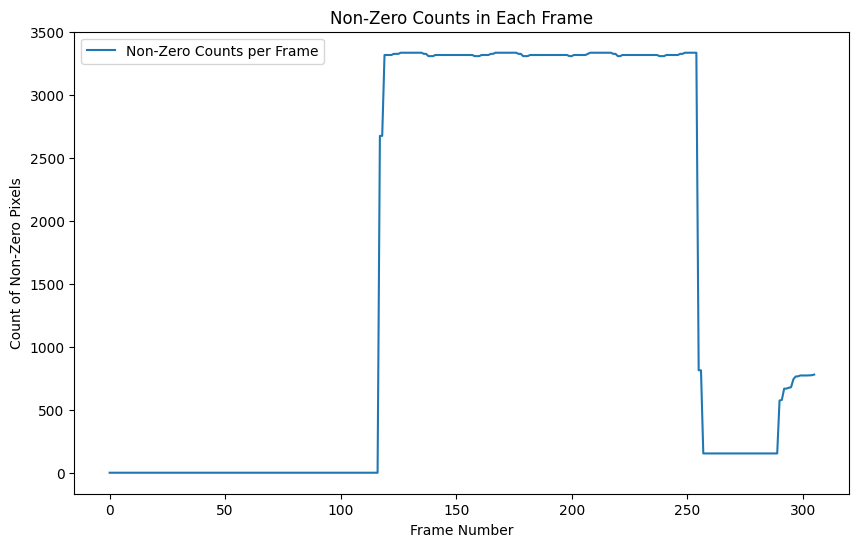

In [2]:
import cv2
import numpy as np
import time  
import matplotlib.pyplot as plt

video_path = r"C:\Users\skybl\Desktop\大三上_逢甲\進階專題\簡報用素材\運算錄影.mp4"

# 創建 VideoCapture 物件
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("無法打開視頻檔案")
    exit()


# 活動量總和
total_nonzero = 0

# 活動量紀錄
nonzero_counts = []
# 初始化平均影像
ret, frame = cap.read()
avg = cv2.blur(frame, (4, 4))
avg_float = np.float32(avg)

start_time = time.time()

while(cap.isOpened()):
  ret, frame = cap.read()
  
  # 若讀取至影片結尾
  if ret == False:
    break
  
  # 模糊處理
  blur = cv2.blur(frame, (4, 4))

  # 計算目前影格與平均影像的差異值
  diff = cv2.absdiff(avg, blur)
  
  # 將圖片轉為灰階
  gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

  # 篩選出變動程度大於門檻值的區域
  ret, thresh = cv2.threshold(gray, 25, 255, cv2.THRESH_BINARY)

  # 使用型態轉換函數去除雜訊
  kernel = np.ones((5, 5), np.uint8)
  thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
  thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
  count_nonzero = np.count_nonzero(thresh)
  total_nonzero += count_nonzero
  nonzero_counts.append(count_nonzero)

end_time = time.time()

# 釋放 VideoCapture 物件
cap.release()
cv2.destroyAllWindows()

print(f"程式運行時間：{end_time - start_time} 秒")
print(f"活動量: {total_nonzero}")

# 繪製折線圖
plt.figure(figsize=(10, 6))
plt.plot(nonzero_counts, label='Non-Zero Counts per Frame')
plt.title('Non-Zero Counts in Each Frame')
plt.xlabel('Frame Number')
plt.ylabel('Count of Non-Zero Pixels')
plt.legend()
plt.show()

程式運行時間：4.994130849838257 秒
活動量: 48629694


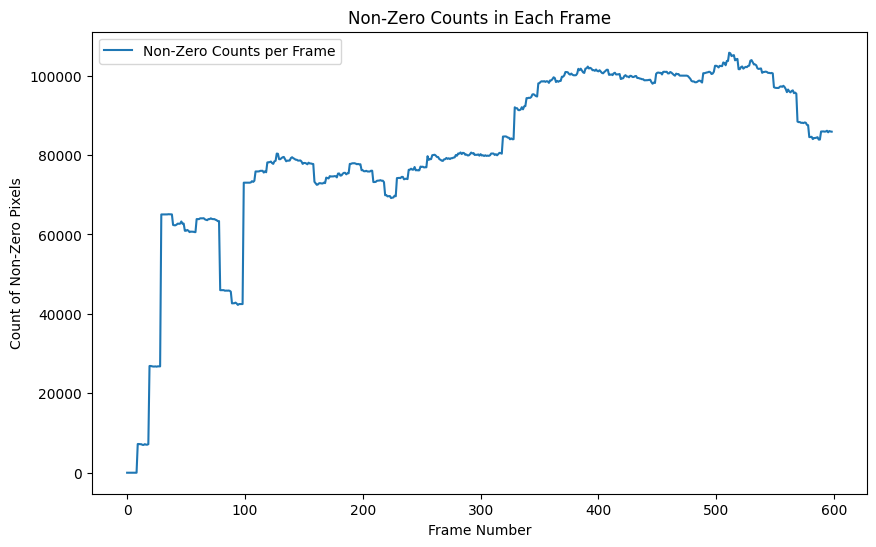

In [4]:
import cv2
import numpy as np
import time  
import matplotlib.pyplot as plt

video_path = r"C:\Users\skybl\Desktop\大三上_逢甲\進階專題\水鹿影片\水鹿1.mp4"

# 創建 VideoCapture 物件
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("無法打開視頻檔案")
    exit()


# 活動量總和
total_nonzero = 0

# 活動量紀錄
nonzero_counts = []
# 初始化平均影像
ret, frame = cap.read()
avg = cv2.blur(frame, (4, 4))
avg_float = np.float32(avg)

start_time = time.time()

while(cap.isOpened()):
  ret, frame = cap.read()
  
  # 若讀取至影片結尾
  if ret == False:
    break
  
  # 模糊處理
  blur = cv2.blur(frame, (4, 4))

  # 計算目前影格與平均影像的差異值
  diff = cv2.absdiff(avg, blur)
  
  # 將圖片轉為灰階
  gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

  # 篩選出變動程度大於門檻值的區域
  ret, thresh = cv2.threshold(gray, 25, 255, cv2.THRESH_BINARY)

  # 使用型態轉換函數去除雜訊
  kernel = np.ones((5, 5), np.uint8)
  thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
  thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
  count_nonzero = np.count_nonzero(thresh)
  total_nonzero += count_nonzero
  nonzero_counts.append(count_nonzero)

end_time = time.time()

# 釋放 VideoCapture 物件
cap.release()
cv2.destroyAllWindows()

print(f"程式運行時間：{end_time - start_time} 秒")
print(f"活動量: {total_nonzero}")

# 繪製折線圖
plt.figure(figsize=(10, 6))
plt.plot(nonzero_counts, label='Non-Zero Counts per Frame')
plt.title('Non-Zero Counts in Each Frame')
plt.xlabel('Frame Number')
plt.ylabel('Count of Non-Zero Pixels')
plt.legend()
plt.show()